<a href="https://colab.research.google.com/github/sulthanalihsan/data-science-2026/blob/main/Pertemuan9_Muhamad_Sulthan_Al_Ihsan_250401020154.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 9 — Algoritma Klasifikasi (Bagian 1)
**Nama  :** Muhammad Sulthan Al Ihsan

**NIM   :** 250401020154

**Mata Kuliah:** Data Science —  S1 PJJ Informatika

**Kelas:** IF401

# **Coba Coba**

# **3. Logistic Regression**

In [13]:
from scipy.special import expit # fungsi sigmoid
import numpy as np
z = np.array([-4, -1, 0, 1, 4])
prob = expit(z) # atau 1/(1+np.exp(-z))
print(prob.round(3))
# [0.018 0.269 0.5 0.731 0.982]

[0.018 0.269 0.5   0.731 0.982]


In [14]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# ── 0. Load Dataset (Example) ────────────────────
data = load_iris()
X = data.data
y = (data.target == 0).astype(int) # Binary classification example

# ── 1. Load & Split ──────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ── 2. Scaling ───────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ── 3. Fit Model ─────────────────────────────────
model = LogisticRegression(C=1.0, random_state=42)
model.fit(X_train_s, y_train)

# ── 4. Prediksi Kelas & Probabilitas ─────────────
y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

print(f"β0 (intercept): {model.intercept_[0]:.3f}")
print(f"β (koefisien): {model.coef_[0].round(3)}")
print(f"Akurasi: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))

β0 (intercept): -2.316
β (koefisien): [-0.919  1.325 -1.636 -1.54 ]
Akurasi: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# **4. Decision Tree**

Akurasi: 1.000

Feature Importance:
               Fitur  Importance
2  petal length (cm)         1.0
0  sepal length (cm)         0.0
1   sepal width (cm)         0.0
3   petal width (cm)         0.0


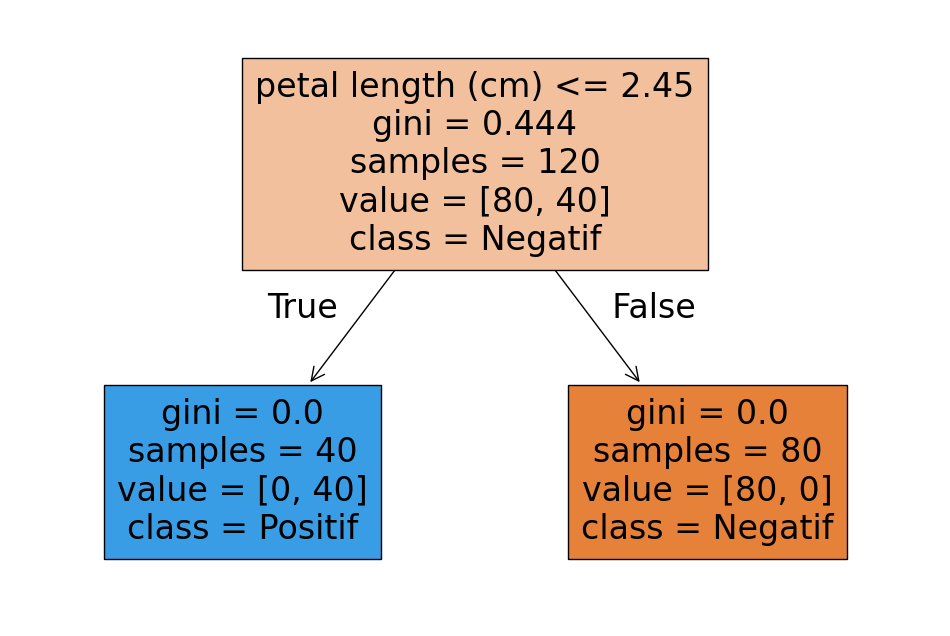

In [15]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# ── 1. Split ───────────────────────────────────────
# X and y are already defined from the previous cell
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ── 2. Fit Model ───────────────────────────────────
model = DecisionTreeClassifier(
    criterion='gini', max_depth=4,
    min_samples_leaf=5, random_state=42)
model.fit(X_train, y_train)

# ── 3. Prediksi & Evaluasi ─────────────────────────
y_pred = model.predict(X_test)
print(f"Akurasi: {accuracy_score(y_test, y_pred):.3f}")

# ── 4. Feature Importance ──────────────────────────
# Menggunakan data.feature_names karena X adalah numpy array
importance = pd.DataFrame({
    'Fitur': data.feature_names,
    'Importance': model.feature_importances_}
).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance.head())

# ── 5. Visualisasi Pohon ───────────────────────────
plt.figure(figsize=(12, 8))
plot_tree(model,
          feature_names=data.feature_names,
          class_names=['Negatif','Positif'],
          filled=True)
plt.show()

# **6. Aktivitas Hands-on: Prediksi Diagnosi**

Langkah 1: Load & EDA Singkat

In [16]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target # 0=malignant, 1=benign
print('Shape:', X.shape)
print('Distribusi target:')
print(pd.Series(y).value_counts(normalize=True).round(3))

Shape: (569, 30)
Distribusi target:
1    0.627
0    0.373
Name: proportion, dtype: float64


catatan :
berhasil memuat dan merapikan data diagnosa kanker payudara. Data siap digunakan untuk melatih model klasifikasi untuk memprediksi apakah sebuah benjolan bersifat ganas atau jinak berdasarkan 30 ciri fisik yang ada.


---



Langkah 2: Preprocessing

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

catatan : di sini kita bagi data menjadi dua bagian: satu untuk melatih model dan satu untuk mengujinya. kita samakan skala semua fitur agar model bisa belajar dgn akurat.


---



Langkah 3: Latih Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)
coef_df = pd.DataFrame({'Fitur': X.columns,
'Koefisien': log_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)
print(coef_df.head())

                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


catatan :
di langkah ini, pembuatan model Logistic Regression dimulai dengan mengatur *max_iter* yang cukup besar agar proses pembelajaran berjalan tuntas. Model kemudian mempelajari pola dari data latih yang sudah diatur skalanya. lalu, model langsung melakukan prediksi pada data uji. Terakhir, dilakukan pemeriksaan fitur mana yang paling berpengaruh terhadap hasil diagnosis berdasarkan nilai koefisiennya.


---



Langkah 4: Latih Decision Tree

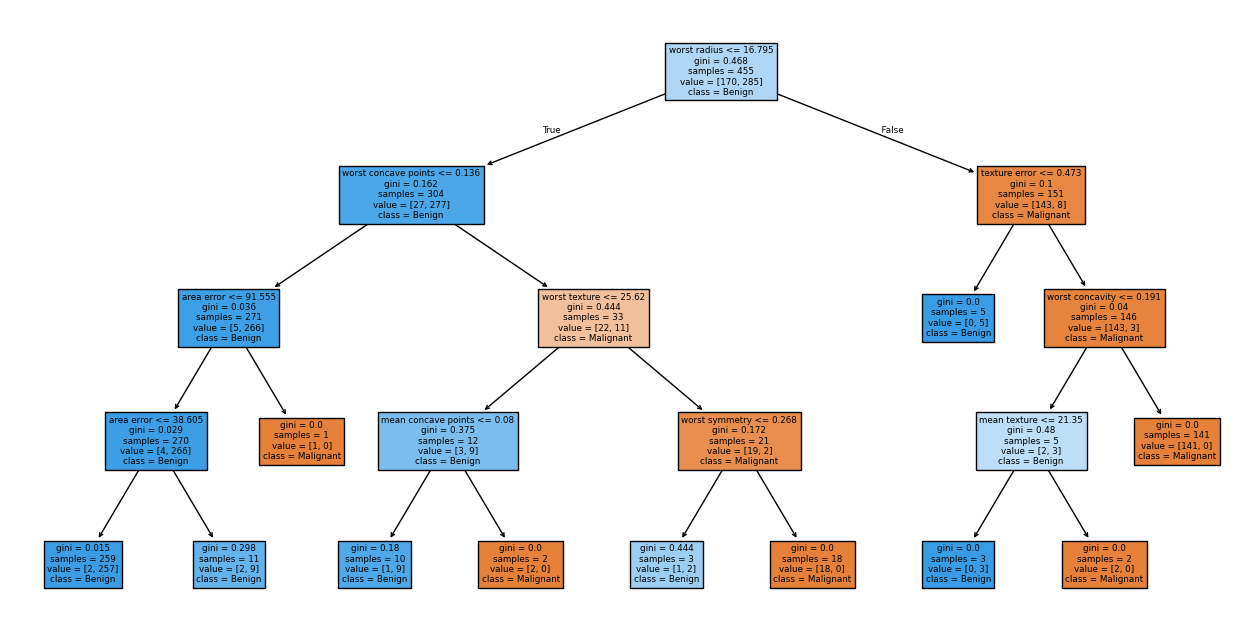

In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
tree_model = DecisionTreeClassifier(max_depth=4,
random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
plt.figure(figsize=(16, 8))
plot_tree(tree_model, feature_names=X.columns,
class_names=['Malignant','Benign'], filled=True)
plt.show()

catatan :
di bagian ini, pembuatan model Decision Tree dimulai dengan membatasi kedalaman (maks 4 tingkat) pohon agar tetap sederhana dan mudah dipahami. Model mempelajari pola langsung dari data asli tanpa penyetaraan skala. Setelah prediksi dihasilkan, alur logika keputusan divisualisasikan dalam bentuk diagram pohon untuk memperlihatkan fitur mana yang paling menentukan diagnosis Ganas atau Jinak.


---



Langkah 5: Evaluasi & Bandingkan

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Menyiapkan list untuk menyimpan hasil
results = []

# Iterasi untuk menghitung metrik setiap model
for name, y_pred in [('Logistic Regression', y_pred_log), ('Decision Tree', y_pred_tree)]:
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

# Membuat DataFrame dan menampilkannya sebagai tabel
df_results = pd.DataFrame(results)
display(df_results.round(3))

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.982,0.986,0.986,0.986
1,Decision Tree,0.939,0.958,0.944,0.951


catatan :

di bagian ini, performa kedua model diuji. beberapa metrik seperti akurasi, presisi, sensitivitas/recall, dan F1-score dihitung untuk melihat seberapa bgus model dalam menebak diagnosis. Hasilnya memperlihatkan Logistic Regression unggul di hampir semua aspek dibandingkan Decision Tree, terutama dalam meminimalkan kesalahan diagnosis.

### Analisis Hasil:

1. **Model dengan Recall Tertinggi:**
   Logistic Regression memiliki nilai **Recall lebih tinggi (0.986)** dibandingkan Decision Tree (0.944). artinya Logistic Regression jauh lebih oke dalam menemukan kasus positif kanker yang sebenarnya.

2. **Pentingnya Recall pada Diagnosis Kanker:**
   Recall menjadi metrik paling kritis karena dalam dunia medis, melewatkan pasien yang sakit (False Negative) jauh lebih berbahaya daripada salah menduga orang sehat sebagai sakit. Jika Recall rendah, ada pasien kanker yang tidak terdeteksi, sehingga mereka tidak mendapatkan pengobatan segera yang bisa berakibat fatal. Accuracy bisa menipu jika jumlah data tidak seimbang, tapi Recall memastikan hampir tidak ada kasus sakit yang terlewat.

3. **Perbedaan Performa:**
   Terdapat perbedaan performa yang cukup terlihat. Logistic Regression mencapai akurasi **98.2%**, sementara Decision Tree hanya **93.9%**. Jadi, untuk kasus ini, Logistic Regression memberikan hasil yang lebih stabil dan akurat.
